# Homework 1: recomendation systems

In [1]:
import numpy as np
import pandas

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

SEED = 123456789
rng = np.random.default_rng(SEED)

## Dataset

In this homework, we are working with the [Movie Lens dataset](https://grouplens.org/datasets/movielens/).
To save computational resources, please use [the educational version](https://files.grouplens.org/datasets/movielens/ml-latest-small.zip).

Download the dataset, unpack it, make sure it is located in `../data/ml-latest-small/` relative to this notebook.

For convinience, we remap all userIds and movieIds into sequential indices, and save the dataset in a faster format.

In [2]:
data = pandas.read_csv('../data/ml-latest-small/ratings.csv')

userId_to_index = {}
movieId_to_index = {}

user_counter = 0
movie_counter = 0

for k in range(len(data)):
    row = data.iloc[k]
    userId = int(row['userId'])
    movieId = int(row['movieId'])

    if userId not in userId_to_index:
        userId_to_index[userId] = user_counter
        user_counter += 1

    if movieId not in movieId_to_index:
        movieId_to_index[movieId] = movie_counter
        movie_counter += 1

for k in range(len(data)):
    row = data.iloc[k]
    userId = int(row['userId'])
    movieId = int(row['movieId'])

    data.loc[k, 'userId'] = userId_to_index[userId]
    data.loc[k, 'movieId'] = movieId_to_index[movieId]

In [3]:
data

,userId,movieId,rating,timestamp
0,0,0,4.0,964982703
1,0,1,4.0,964981247
2,0,2,4.0,964982224
3,0,3,5.0,964983815
4,0,4,5.0,964982931
...,...,...,...,...
100831,609,3120,4.0,1493848402
100832,609,2035,5.0,1493850091
100833,609,3121,5.0,1494273047
100834,609,1392,5.0,1493846352


In [4]:
user_counter = {}
movie_counter = {}

for k in range(len(data)):
    row = data.iloc[k]
    userId = int(row['userId'])
    movieId = int(row['movieId'])

    user_counter[userId] = user_counter.get(userId, 0) + 1
    movie_counter[movieId] = movie_counter.get(movieId, 0) + 1

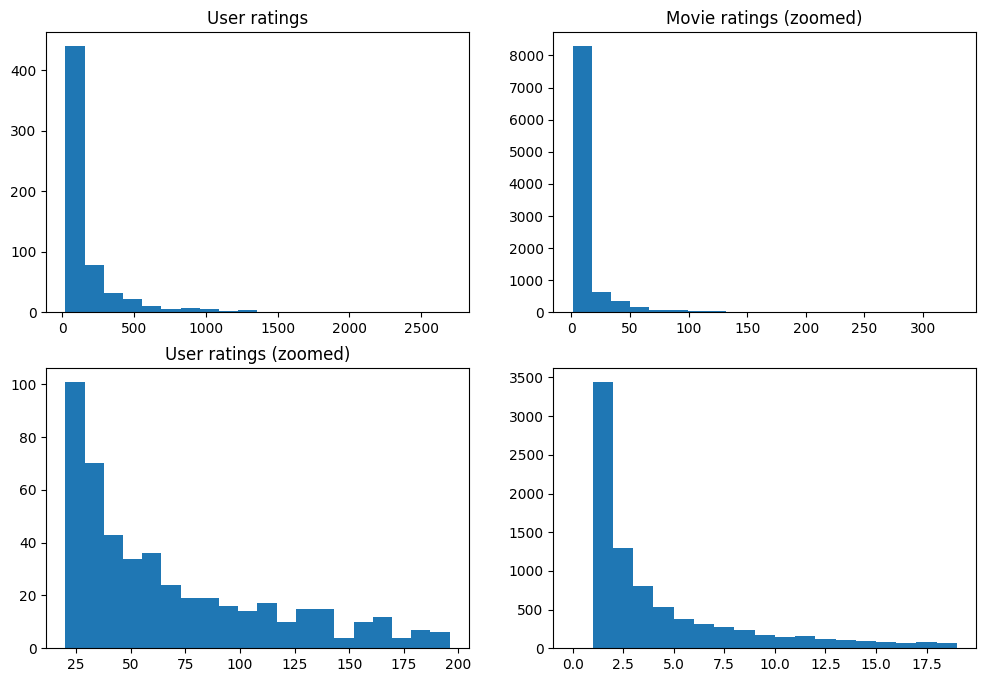

In [5]:
fig = plt.figure(figsize=(12, 8))
axes = fig.subplots(2, 2)

axes[0, 0].set_title('User ratings')
_ = axes[0, 0].hist(user_counter.values(), bins=20)

axes[1, 0].set_title('User ratings (zoomed)')
_ = axes[1, 0].hist([c for c in user_counter.values() if c < 200], bins=20)

axes[0, 1].set_title('Movie ratings')
_ = axes[0, 1].hist(movie_counter.values(), bins=20)

axes[0, 1].set_title('Movie ratings (zoomed)')
_ = axes[1, 1].hist([c for c in movie_counter.values() if c < 19], bins=np.arange(20))

In [6]:
n_movies_at_least_8 = len([c for c in movie_counter.values() if c > 7])
print(f'{n_movies_at_least_8} / {len(movie_counter)}')

2671 / 9724


## Task 1. Split the dataset into train, validation, test (0.1 points).

- select a subset of the dataset such that each movie has at least 8 ratings, and each user provided at least 8 ratings;
    - remove movies with < 8 ratings;
    - remove users with < 8 ratings;
    - repeat if neccessary;
- **For each user**, randomly split ratings into train, validation, test datasets. Use `2:1:1` split.
- Directly sub-sampling the ratings matrix risks leaving some users without training data.
- Use random number generator with a clearly defined seed (e.g., `rng` at the top), so that the split remains the same when you rerun the notebook.

In [7]:
### subsebset selection
data = ...

### change ... to your code
data_train = ...
data_validation = ...
data_test = ...

## Task 2. Implement classical ALS (0.5 points)

Below you will find a skeleton of the ALS function. Fill the missing code.
- Use `numpy` only.
- don't forget about global, user and item offsets $r_\mathrm{global}$, $r_\mathrm{user}$, $r_\mathrm{item}$:
  - user/item means must be computed after substracting the global mean.

In [8]:
def linear_regression(X, y, alpha=1.0e-3):
    """
    X: (batch, k), y: (batch, )
    """
    n_f = X.shape[1]

    A = X.T @ X + alpha * np.eye(n_f)
    b = X.T @ y

    return np.linalg.solve(A, b)

In [9]:
def als(data, n_latent, alpha, n_iterations=1024):
    ### indices
    user_index = ...
    item_index = ...

    n_users = ...
    n_items = ...
    
    ### users
    P = ...
    ### items
    Q = ...

    global_mean = ...
    user_means = ...
    item_means = ...
    
    for iteration in range(n_iterations):
        for i in range(n_users):
            ...

        for j in range(n_items):
            ...

    return P, Q

## Task 3. Training (0.1 points)

Train ALS on the training dataset, evaluate on the validation dataset. Report training and validation MSE values.

## Task 4. Hyper-parameter optimization (0.2 points)

For each combination of the following parameters:
- `alpha in [1e-3, 1e-2, 1e-1, 1]`;
- `k in [8, 12, 16]`
train ALS, compute MSE on the validation set, find the best hyper-parameters.

Print validation performance of each set of hyper-parameters.

## Task 5. Test (0.1 points)

Retrain ALS with the best-performing hyper-parameters, evaluate on test. Report MSE.

## Task 6*. Genres (optional, 0.5 points)

The dataset also provides genre classification of the movies: `movies.csv`. Using learned latent vectors of the movies, predict genres:
- you can skip hyper-parameter optimization;
- you can use `sklearn` for this task;
- consider using `sklearn.preprocessing.MultiLabelBinarizer` for encoding the genres;
- **for each genre** report accuracy and the random guess accuracy (estimated on label priors from the training set);
- note the special `(no genres listed)` label, handle it appropriately.

In [10]:
genres_all = pandas.read_csv('../data/ml-latest-small/movies.csv', header=1)
genres = {}

for i in range(len(genres_all)):
    movie_id, movie_title, movie_genres = genres_all.loc[i]

    if movie_id in movieId_to_index:
        movie_index = movieId_to_index[movie_id]
        genres[movie_index] = movie_genres.split('|')

del genres_all

In [11]:
for _, (index, gs) in zip(range(5), genres.items()):
    print(f'{index}: {gs}')

481: ['Adventure', 'Children', 'Fantasy']
1: ['Comedy', 'Romance']
482: ['Comedy', 'Drama', 'Romance']
483: ['Comedy']
2: ['Action', 'Crime', 'Thriller']


In [12]:
print(set([g for _, gs in genres.items() for g in gs]))

{'Action', 'Musical', 'Mystery', 'Fantasy', 'Children', 'Crime', 'Drama', '(no genres listed)', 'Horror', 'War', 'Animation', 'Comedy', 'IMAX', 'Documentary', 'Film-Noir', 'Adventure', 'Thriller', 'Sci-Fi', 'Romance', 'Western'}


## Task 7**. Using genres for predictions (possible exam project)

Implement and train a modification of ALS where item latent vectors are not learnable parameters but instead means of their genre latent vectors (the latter are trainable).
Before attempting this task contact the lecturer to avoid collisions with other students.

*Other similar task might be available for the exam project, please contact the lecturer.*

## How to submit your solution

Please send the following files via teams:
- the notebook converted into pdf (one can convert into pdf using the jupyter's menu, requires pandoc);
- the notebook itself (`.ipynb` file);
- the files should be named `<your name>_<your surname>_homework_01.ipynb` (and the same for the pdf).

**Deadline: the 31st of March 2026**